# Between-Class Analysis PCA - meaudret dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## meaudret dataset

In [2]:
from scientisttools.datasets import meaudret
meaudret._fields

('actif', 'sup_var', 'data')

In [3]:
# overall dataset
data = meaudret.data
data.info()

<class 'pandas.DataFrame'>
Index: 20 entries, sp_1 to wi_5
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temp                 20 non-null     int64  
 1   Flow                 20 non-null     int64  
 2   pH                   20 non-null     float64
 3   Cond                 20 non-null     int64  
 4   Bdo5                 20 non-null     float64
 5   Oxyd                 20 non-null     float64
 6   Ammo                 20 non-null     float64
 7   Nitr                 20 non-null     float64
 8   Phos                 20 non-null     float64
 9   season               20 non-null     str    
 10  site                 20 non-null     str    
 11  Ephemera_danica      20 non-null     int64  
 12  Baetis_sp            20 non-null     int64  
 13  Baetis_rhodani       20 non-null     int64  
 14  Baetis_niger         20 non-null     int64  
 15  Baetis_muticus       20 non-null     int64  
 16  Cen

## Instanciation & training

In [4]:
# instanciation
from scientisttools import PCA
clf = PCA(group=9,sup_var=range(10,24))

### `fit` function

In [5]:
# fit function
clf.fit(data)

,group,9
,sup_var,"range(10, 24)"
,scale_unit,True
,iv,None
,ortho,False
,partial,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,ind_sup,None


### `fit_transform` function

In [6]:
# fit_transform function - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3
sp_1,-1.428729,0.789597,-1.444892
sp_2,-0.432185,0.932332,-0.114448
sp_3,-1.891803,0.840076,-0.785281
sp_4,-2.154019,0.912367,-0.588322
sp_5,-2.091587,1.060473,-0.296254
su_1,-0.793930,1.233640,-0.496149
su_2,3.253113,1.436311,2.006361
su_3,3.189961,1.054777,1.043430
su_4,1.966470,1.206879,0.423705
su_5,0.088672,0.836320,-0.675581


### `transform` function

In [7]:
# transform function - individuals coordinates
ind_coord = clf.transform(meaudret.actif)
ind_coord

,Dim1,Dim2,Dim3
sp_1,-1.428729,0.789597,-1.444892
sp_2,-0.432185,0.932332,-0.114448
sp_3,-1.891803,0.840076,-0.785281
sp_4,-2.154019,0.912367,-0.588322
sp_5,-2.091587,1.060473,-0.296254
su_1,-0.793930,1.233640,-0.496149
su_2,3.253113,1.436311,2.006361
su_3,3.189961,1.054777,1.043430
su_4,1.966470,1.206879,0.423705
su_5,0.088672,0.836320,-0.675581


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Principal Component Analysis (PCA)**

*The results are available in the following objects:

name              description
----------------  -----------------------------------------------------
.call_            summary called parameters
.eig_             eigenvalues
.group_           results for the groups
.ind_             results for the individuals
.levels_sup_      results for the supplementary levels
.quali_var_sup_   results for the supplementary qualitative variables
.quanti_var_      results for the quantitative variables
.quanti_var_sup_  results for the supplementary quantitative variables
.ratio_           inertia (ratio) percentage
.svd_             results for generalized singular values decomposition



## Eigen values

In [9]:
# eigenvalues
from scientisttools import get_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,1.706750,0.628322,50.941400,50.941400
Dim2,1.078428,0.513188,32.187865,83.129265
Dim3,0.565240,NaN,16.870735,100.000000


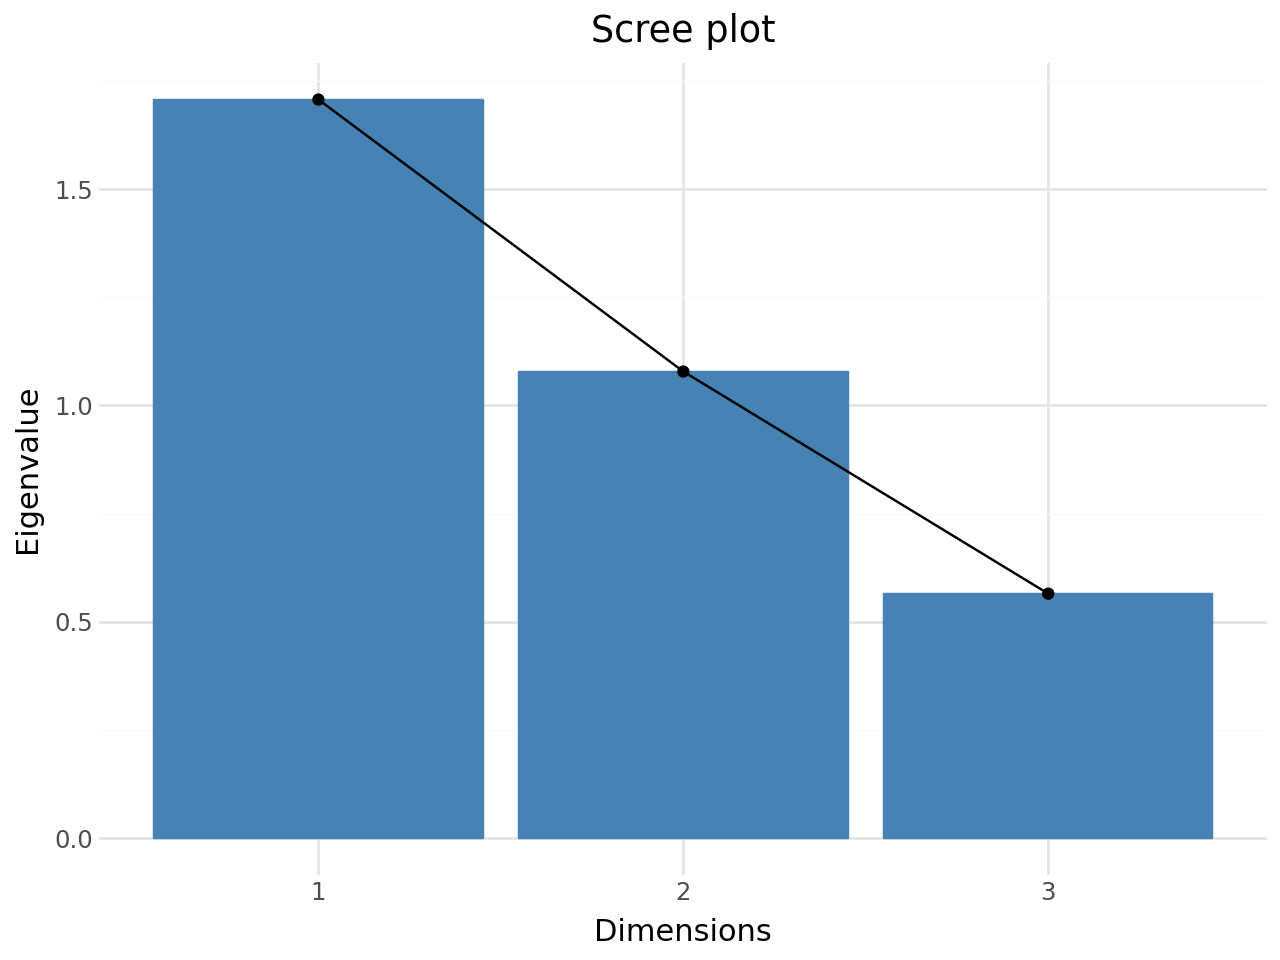

None


In [10]:
# scree plot
from scientisttools import fviz_screeplot
p = fviz_screeplot(clf,choice="eigenvalue")
print(p.show())

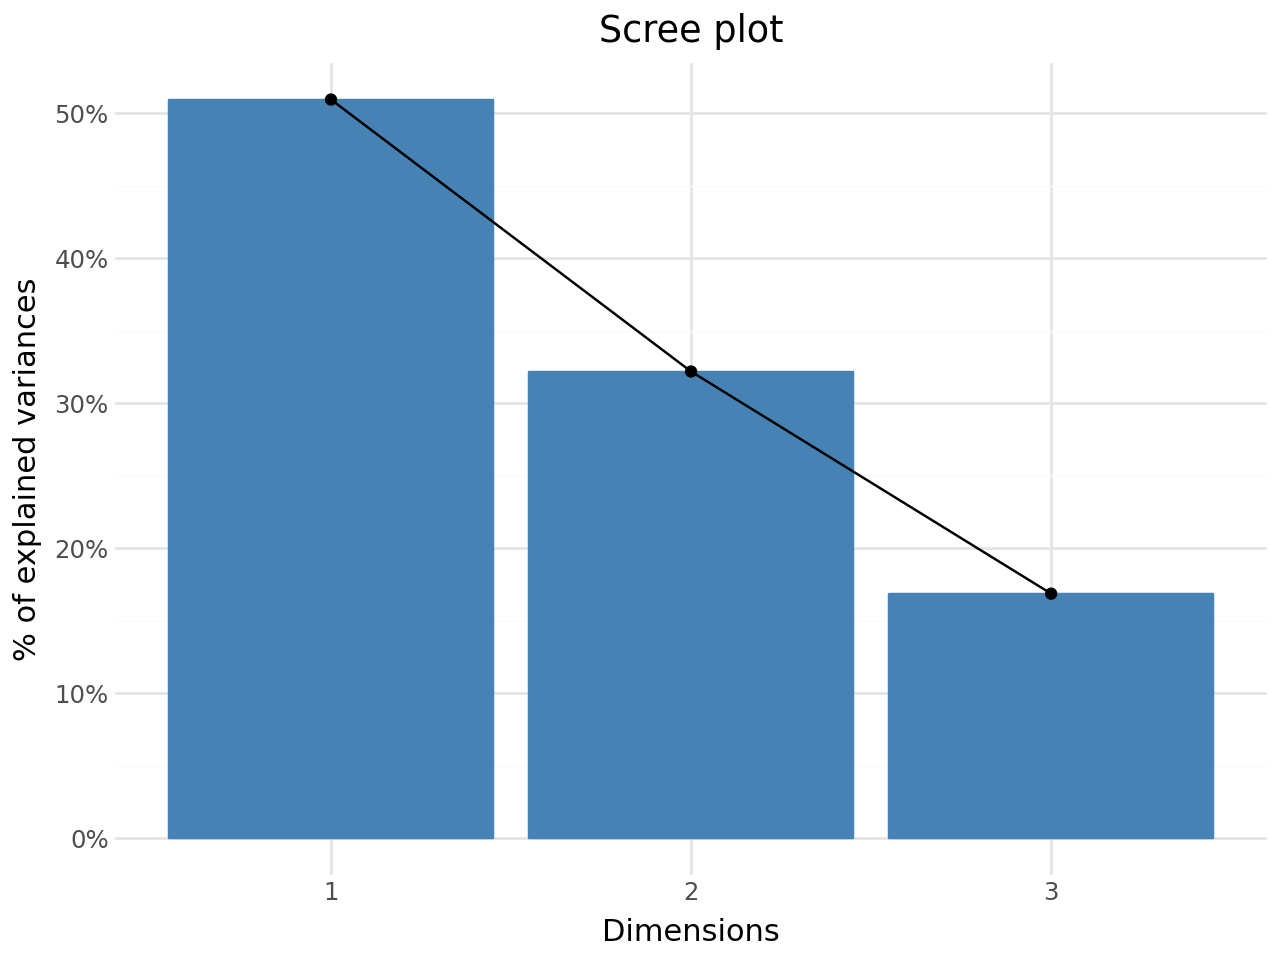

None


In [11]:
# proportion
p = fviz_screeplot(clf,choice="proportion")
print(p.show())

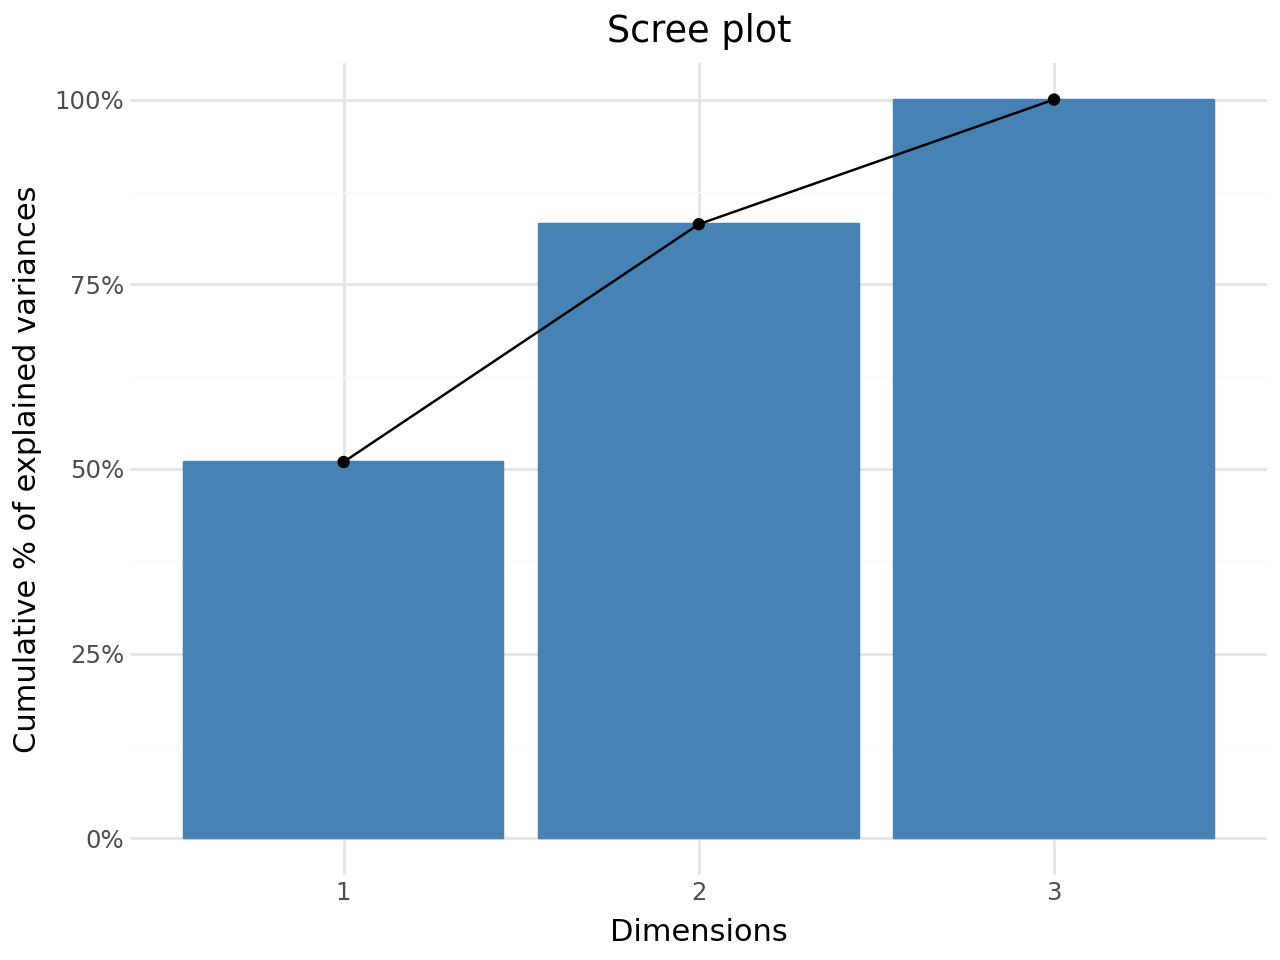

None


In [12]:
# cumulative proportion
p = fviz_screeplot(clf,choice="cumulative")
print(p.show())

## Groups informations

In [13]:
# group informations
group = clf.group_
group._fields

('coord', 'cos2', 'contrib', 'infos')

### Groups coordinates

In [14]:
# groups coordinates
group.coord

,Dim1,Dim2,Dim3
autumn,1.002055,-1.167057,-0.805790
spring,-1.599664,0.906969,-0.645839
summer,1.540857,1.153586,0.460353
winter,-0.943248,-0.893498,0.991276


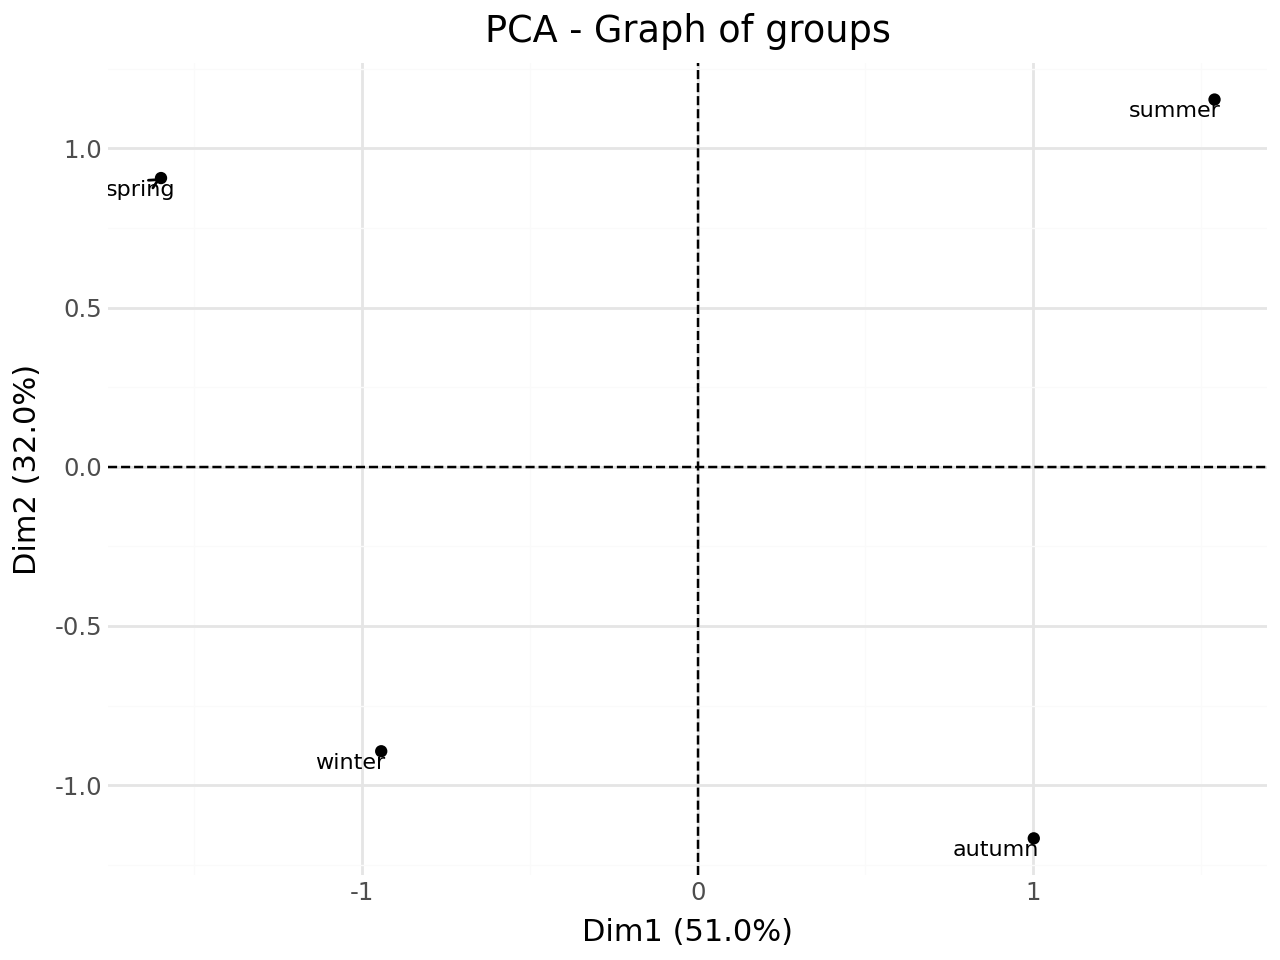

None


In [15]:
# graph of groups
from scientisttools import fviz_scatter, set_axis
p = fviz_scatter(
    obj=clf,
    choice="group",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf,
    title = "PCA - Graph of groups"
)
print(p.show())

### Groups contributions

In [16]:
#group contributions
group.contrib

,Dim1,Dim2,Dim3
autumn,14.707985,31.574230,28.717785
spring,37.482453,19.069252,18.448295
summer,34.777240,30.849526,9.373234
winter,13.032322,18.506992,43.460686


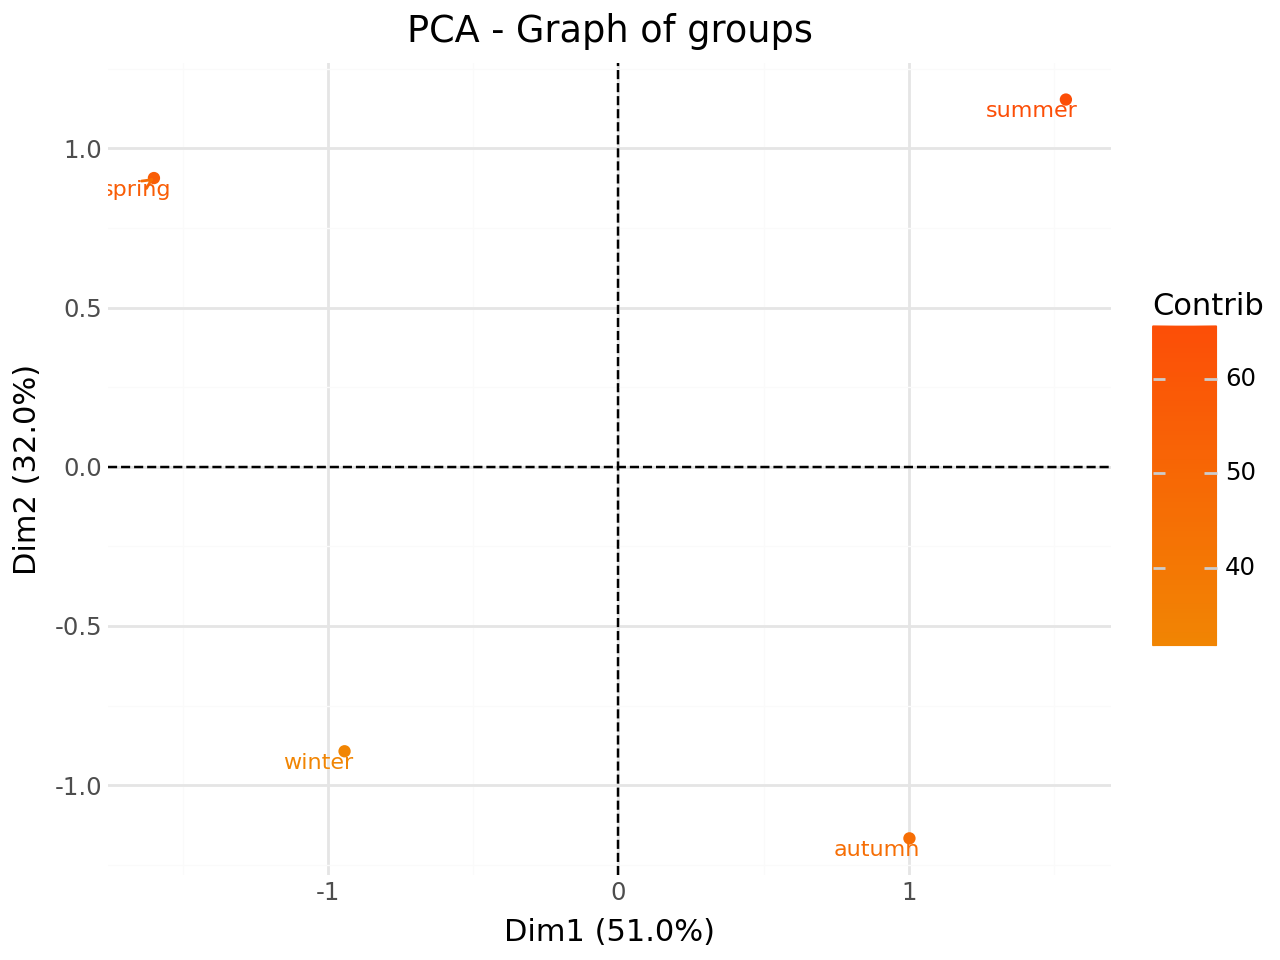

None


In [17]:
# graph of groups - color by contributions
p = fviz_scatter(
    obj=clf,
    choice="group",
    color = "contrib",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf,
    title = "PCA - Graph of groups"
)
print(p.show())

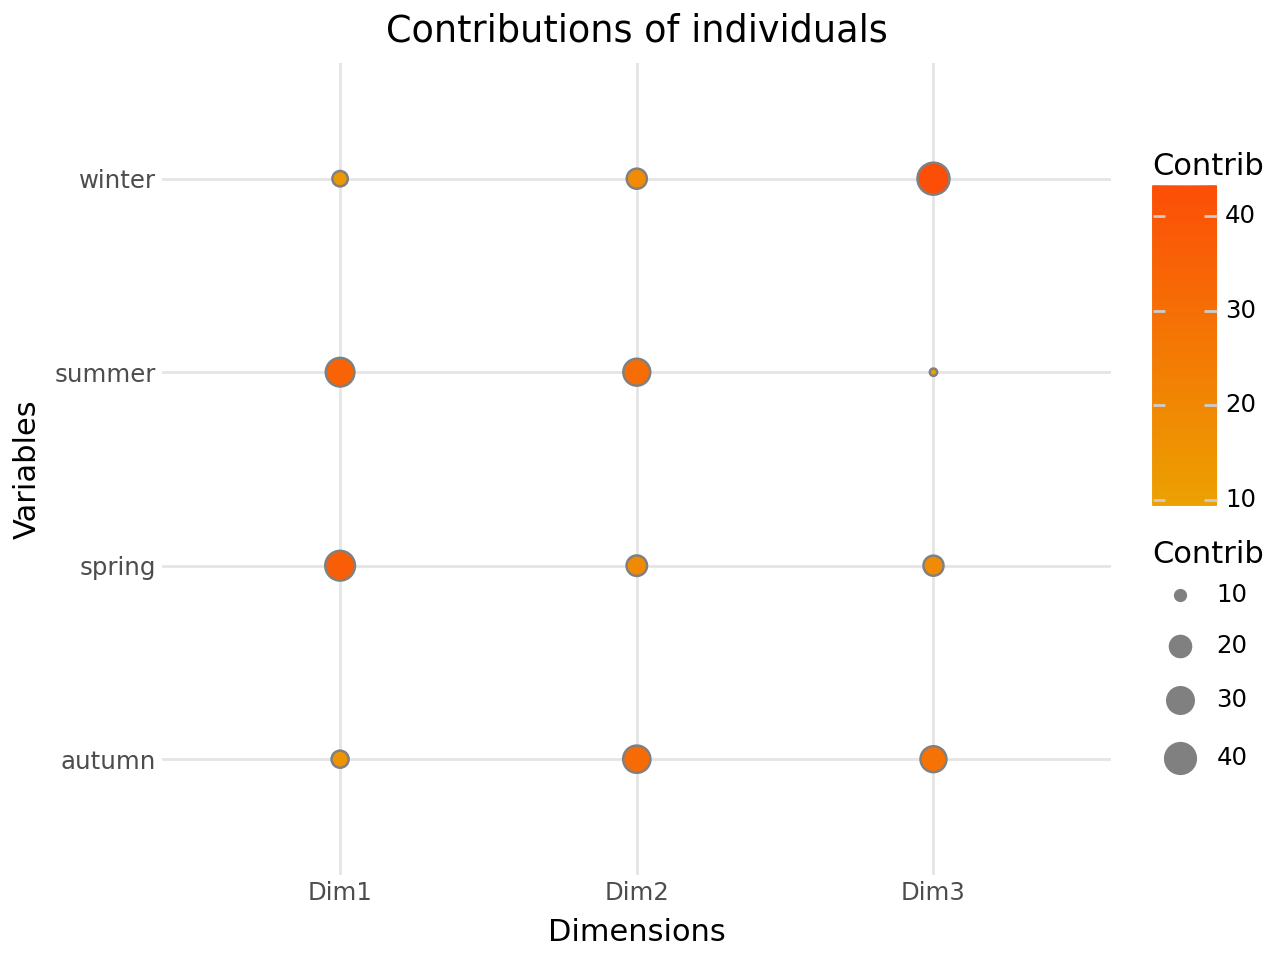

None


In [18]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=group.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

### Groups cos2

In [19]:
# groups cos2
group.cos2

,Dim1,Dim2,Dim3
autumn,0.332992,0.451683,0.215325
spring,0.673645,0.216550,0.109805
summer,0.606149,0.339746,0.054105
winter,0.333142,0.298927,0.367932


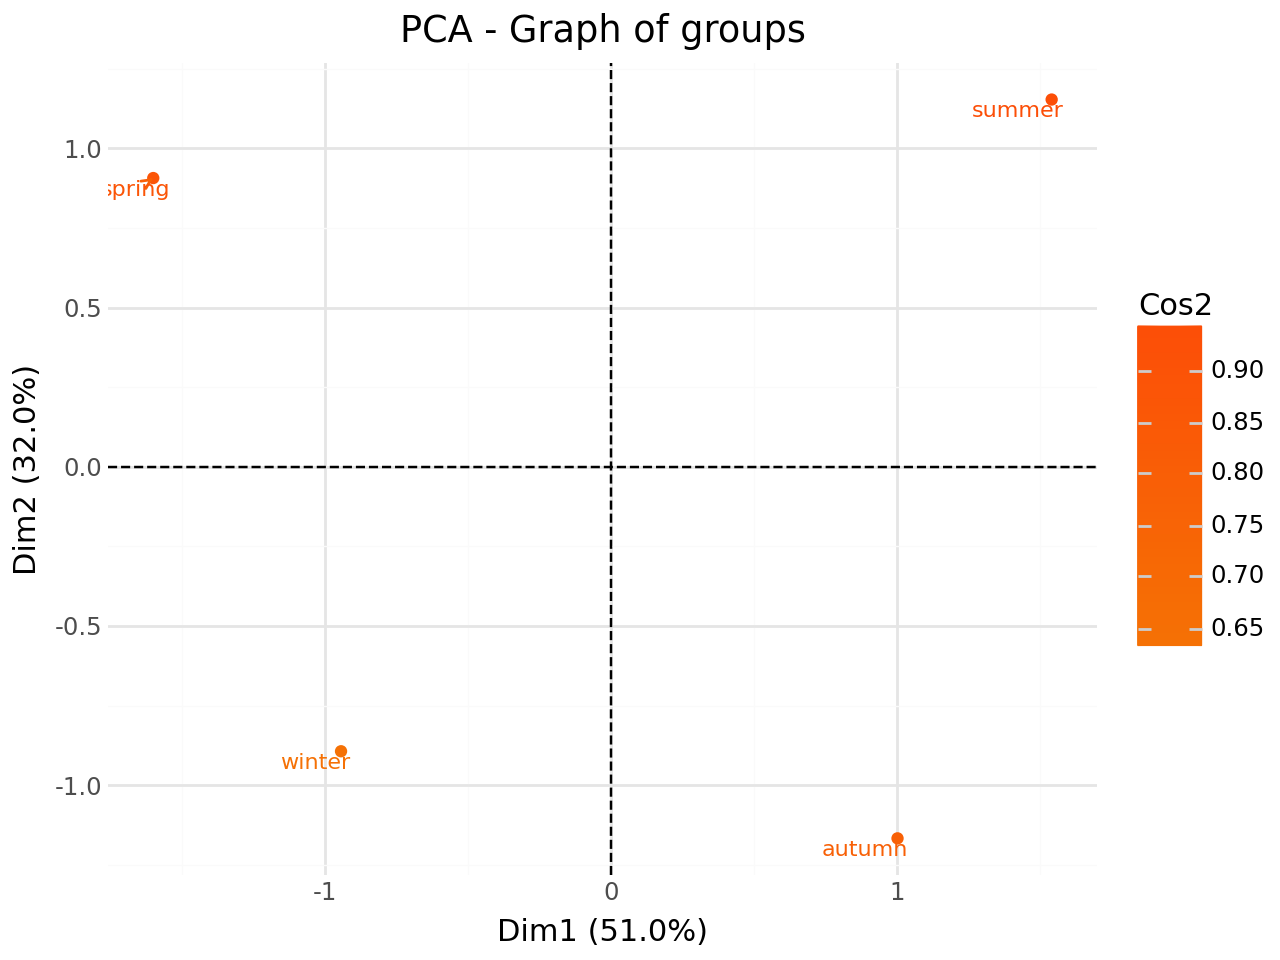

None


In [20]:
# graph of groups - color by contributions
p = fviz_scatter(
    obj=clf,
    choice="group",
    color = "cos2",
    repel = True
)
# set axis
p = set_axis(
    p = p,
    obj=clf,
    title = "PCA - Graph of groups"
)
print(p.show())

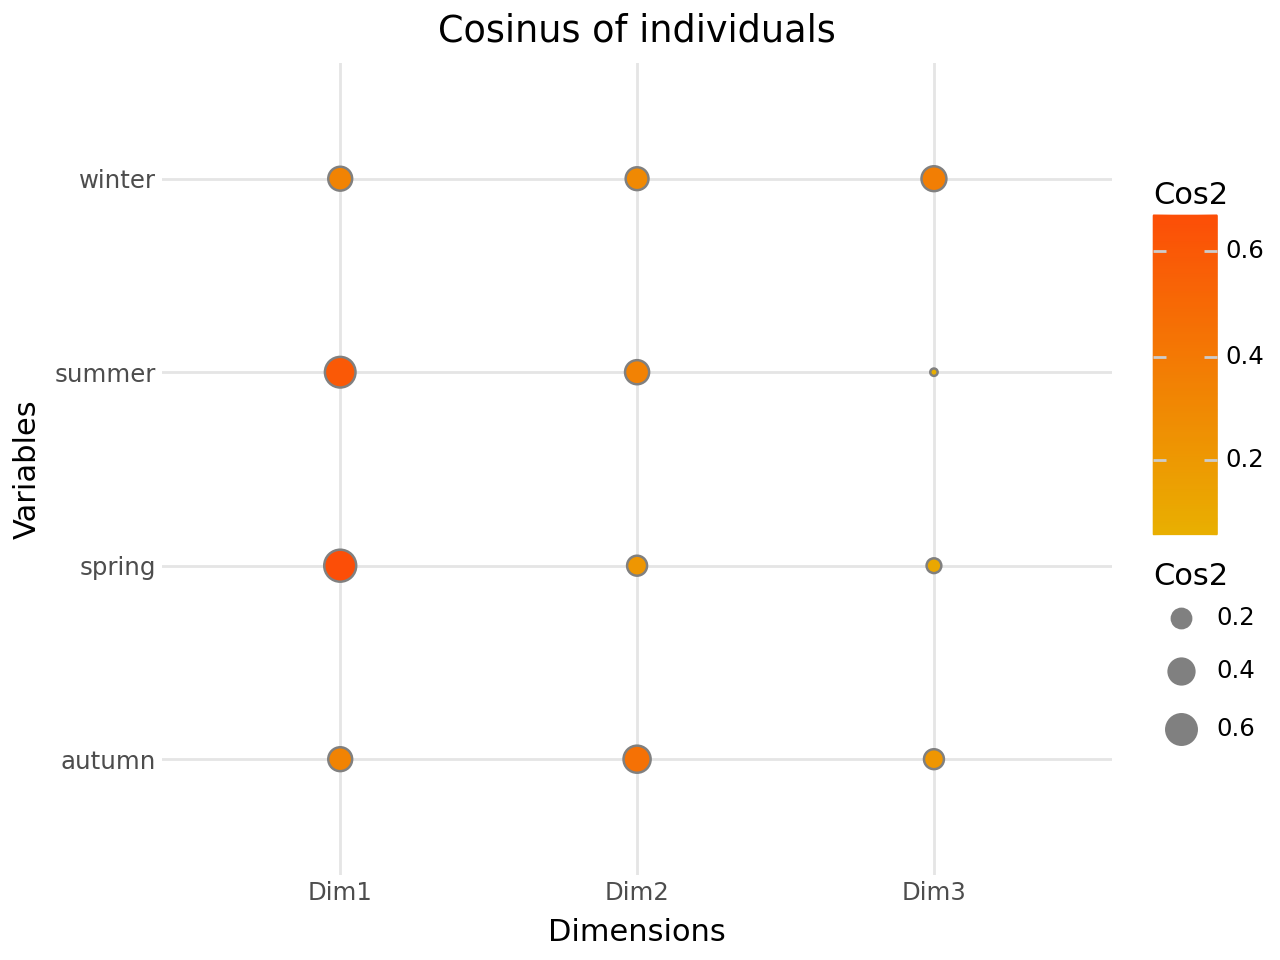

None


In [21]:
# graph of cosinus
p = fviz_corrplot(
    X=group.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

### Group additionals informations

In [22]:
# groups additionals informations
group.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
autumn,0.25,3.015433,0.753858,22.500426
spring,0.25,3.798628,0.949657,28.344434
summer,0.25,3.916926,0.979232,29.227150
winter,0.25,2.670683,0.667671,19.927990


## Individuals informations

In [23]:
#individuals informations
from scientisttools import get_pca
ind = get_pca(clf,"ind")
ind._fields

('coord', 'cos2', 'dist2')

### Individuals coordinates

In [24]:
# individuals coordinates
ind.coord

,Dim1,Dim2,Dim3
sp_1,-1.428729,0.789597,-1.444892
sp_2,-0.432185,0.932332,-0.114448
sp_3,-1.891803,0.840076,-0.785281
sp_4,-2.154019,0.912367,-0.588322
sp_5,-2.091587,1.060473,-0.296254
su_1,-0.793930,1.233640,-0.496149
su_2,3.253113,1.436311,2.006361
su_3,3.189961,1.054777,1.043430
su_4,1.966470,1.206879,0.423705
su_5,0.088672,0.836320,-0.675581


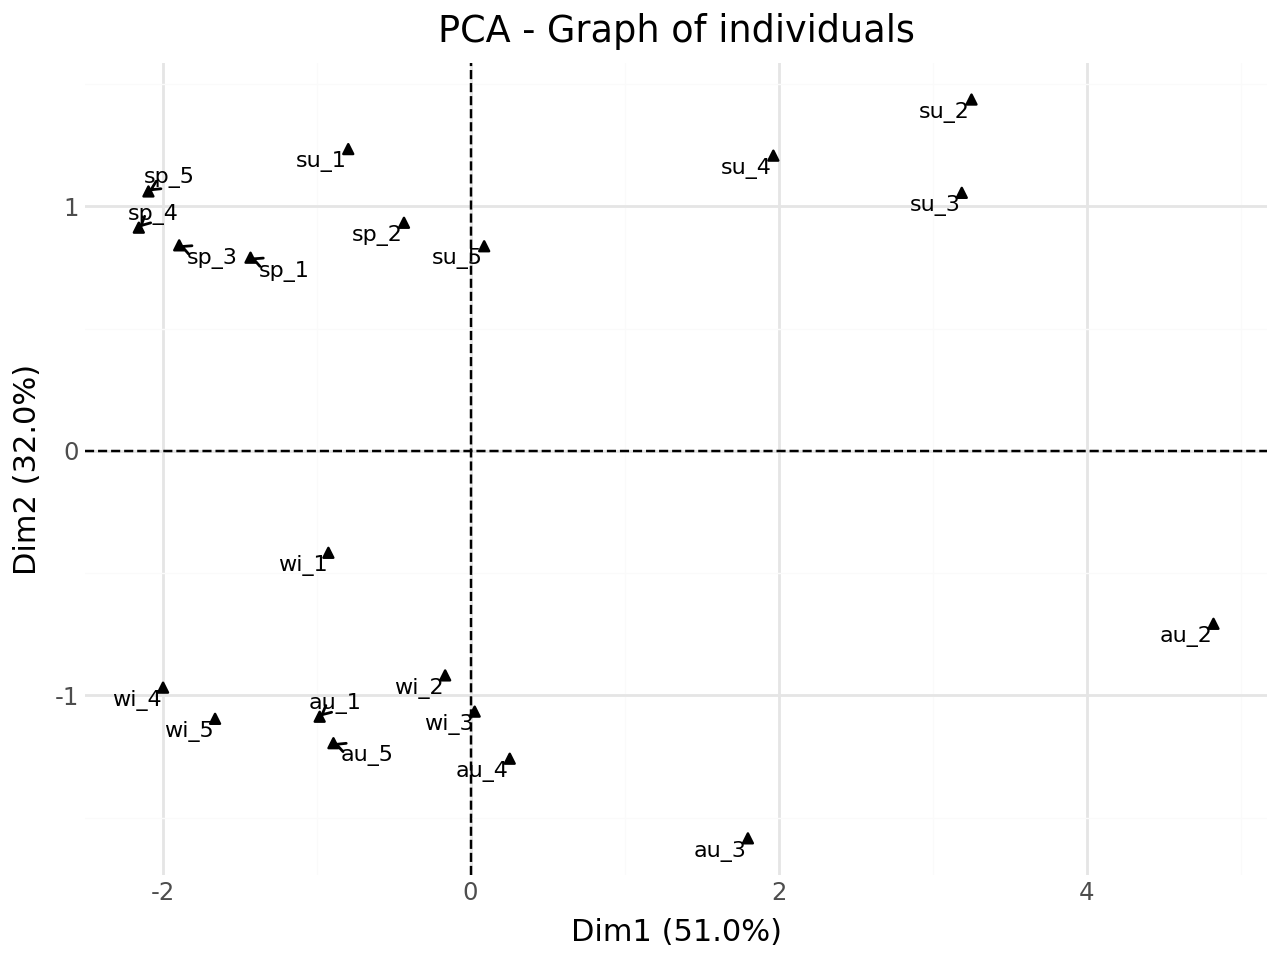

None


In [25]:
# graph of individuals
from plotnine import ggplot
from scientisttools import add_scatter
p = add_scatter(
    p=ggplot(),
    data=ind.coord,
    color="black",
    repel=True
)
# set axis
p = set_axis(
    p = p,
    obj=clf,
    title = "PCA - Graph of individuals"
)
print(p.show())

### Individuals cos2

In [26]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3
sp_1,0.341233,0.104223,0.348998
sp_2,0.098626,0.458982,0.006916
sp_3,0.715244,0.141039,0.123240
sp_4,0.745213,0.133697,0.055592
sp_5,0.682093,0.175344,0.013684
su_1,0.146188,0.352959,0.057091
su_2,0.447902,0.087314,0.170374
su_3,0.770960,0.084291,0.082487
su_4,0.617321,0.232522,0.028659
su_5,0.001604,0.142674,0.093101


### Individuals dist2

In [27]:
# individuals dist2
ind.dist2.to_frame()

,Sq. Dist.
sp_1,5.982024
sp_2,1.893849
sp_3,5.003776
sp_4,6.226132
sp_5,6.413694
su_1,4.311744
su_2,23.627388
su_3,13.198935
su_4,6.264179
su_5,4.902316


## Variables informations

In [28]:
# variables informations
var = get_pca(clf,"var")
var._fields

('coord', 'cos2', 'contrib', 'infos')

### Variables coordinates

In [29]:
# variables coordinates
var.coord

,Dim1,Dim2,Dim3
Temp,0.124905,0.978031,0.016629
Flow,-0.579378,-0.095677,0.472756
pH,-0.492705,-0.060614,-0.397592
Cond,0.553876,-0.184644,0.341975
Bdo5,0.327266,-0.008494,-0.016134
Oxyd,0.248469,0.047366,0.001981
Ammo,0.410986,0.076877,0.039586
Nitr,0.457974,-0.251148,-0.253587
Phos,0.508373,-0.060495,-0.017360


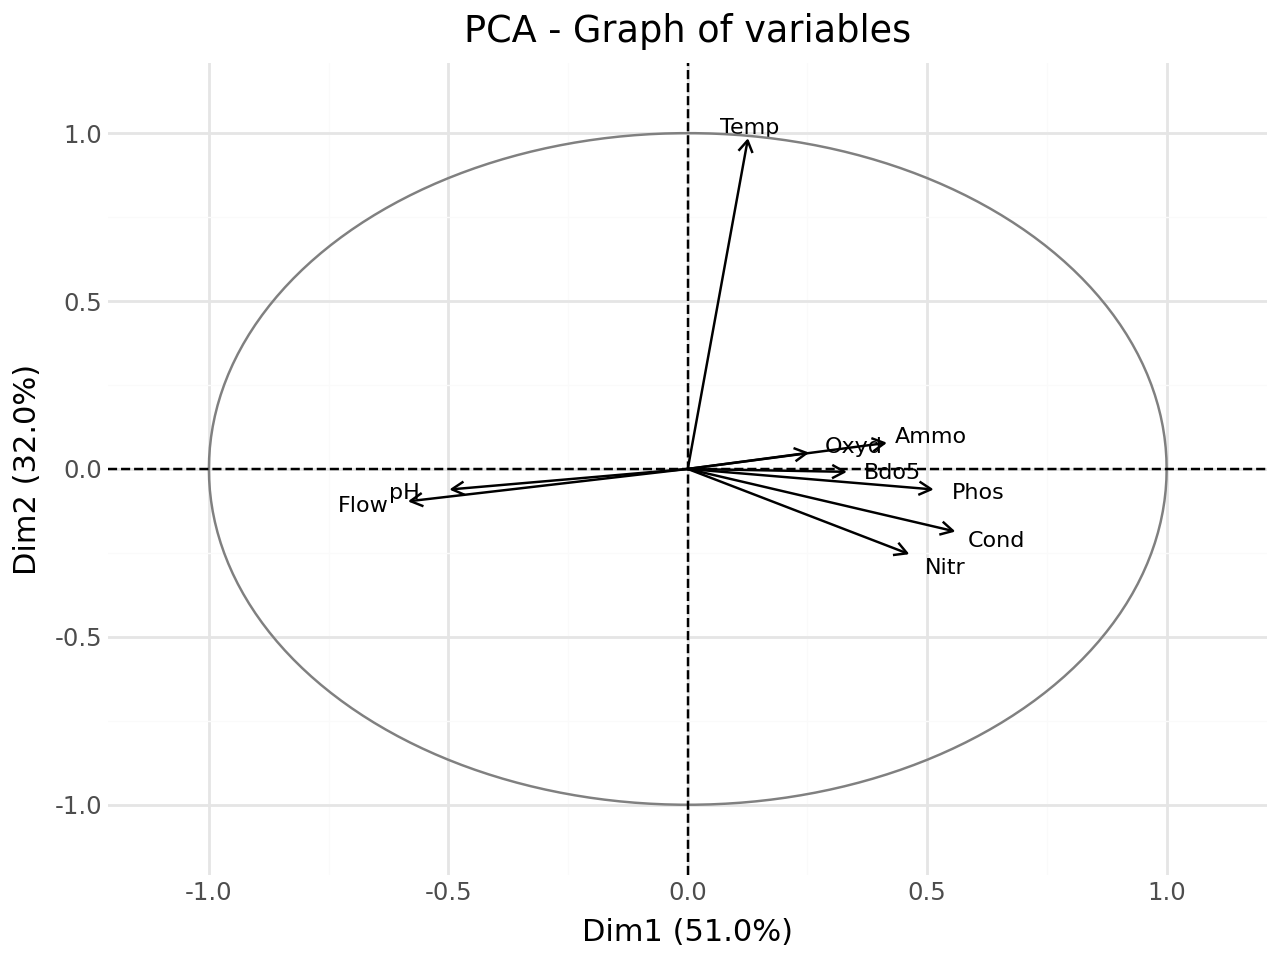

None


In [30]:
# graph of variables - correlation circle
from scientisttools import fviz_pca
p = fviz_pca(
    obj=clf,
    choice="var",
    repel=True,
    quanti_sup=False
)
print(p.show())

### Variables contributions

In [31]:
#variables contributions
var.contrib

,Dim1,Dim2,Dim3
Temp,0.914095,88.698140,0.048922
Flow,19.667702,0.848834,39.540435
pH,14.223414,0.340681,27.966740
Cond,17.974466,3.161401,20.689791
Bdo5,6.275254,0.006691,0.046054
Oxyd,3.617212,0.208040,0.000694
Ammo,9.896575,0.548028,0.277236
Nitr,12.288883,5.848838,11.376814
Phos,15.142400,0.339347,0.053314


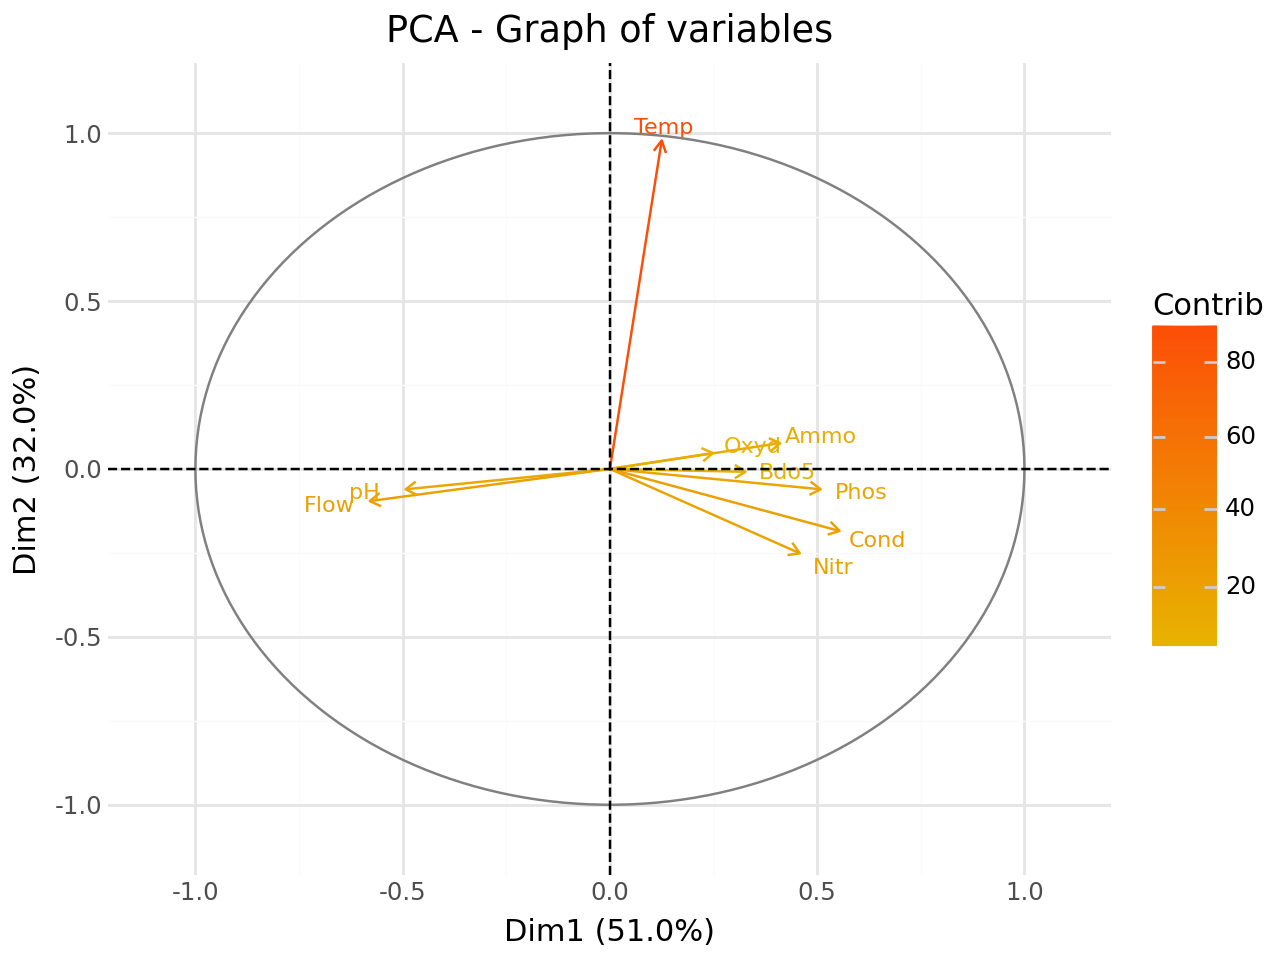

None


In [32]:
# graph of variables - color by contrib
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "contrib",
    repel=True,
    quanti_sup=False
)
print(p.show())

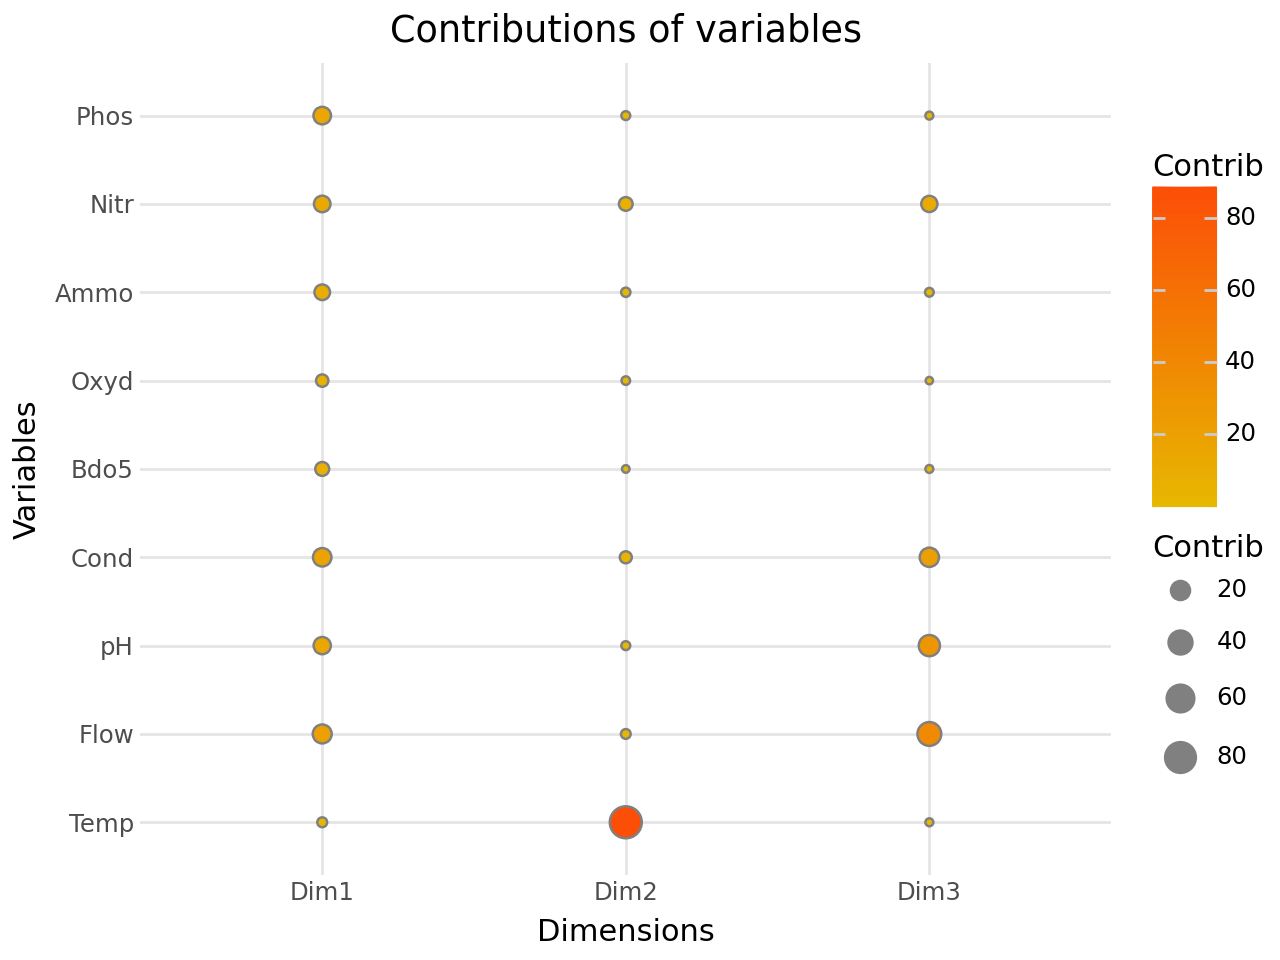

None


In [33]:
# graph of contributions for variables
p = fviz_corrplot(
    X=var.contrib,
    legend_title="Contrib",
    title="Contributions of variables"
)
print(p.show())

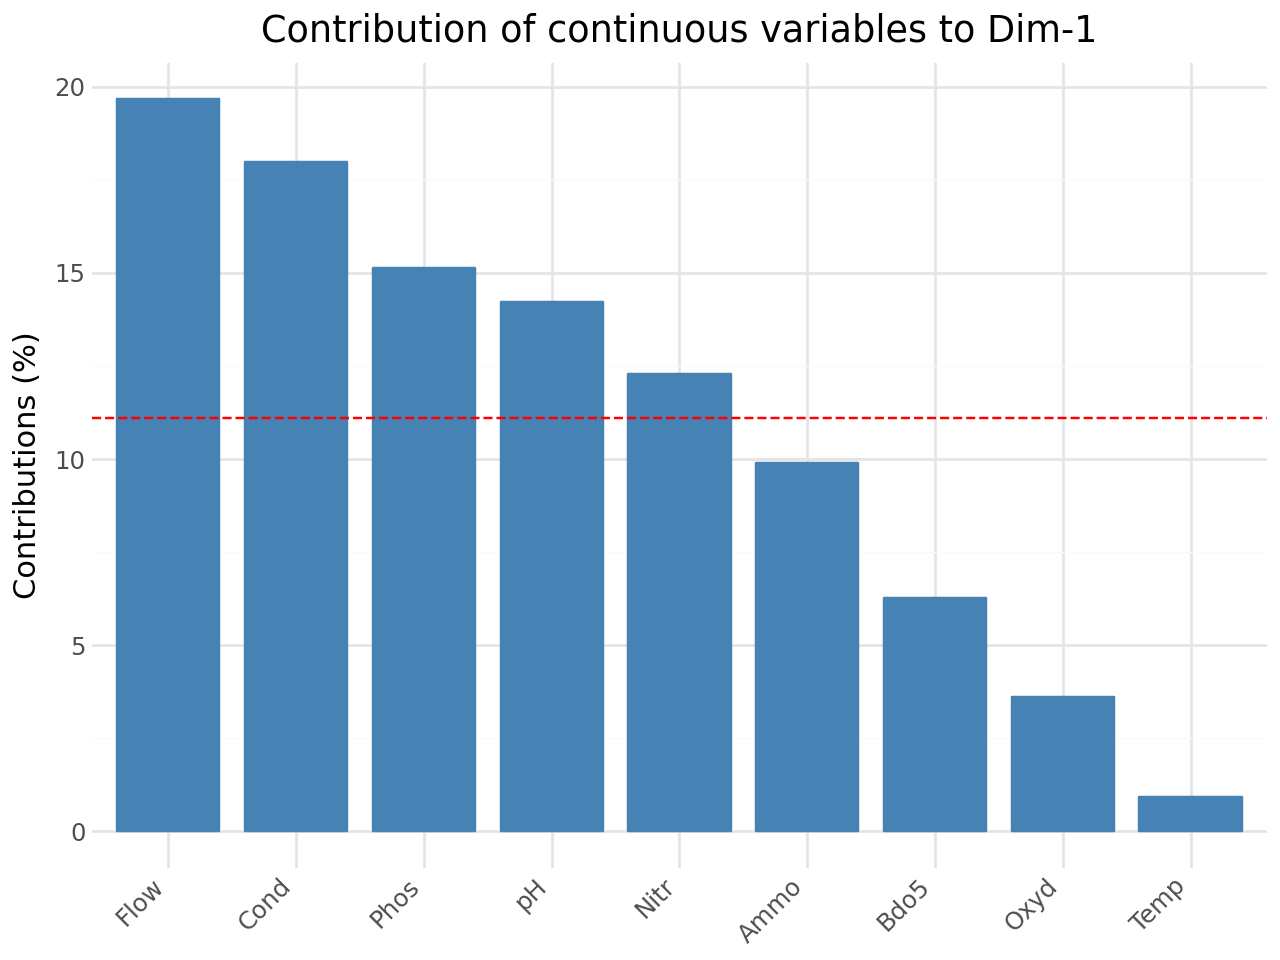

None


In [34]:
# contributions of variables to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables cos2

In [35]:
# variables cos2
var.cos2

,Dim1,Dim2,Dim3
Temp,0.016044,0.983672,0.000284
Flow,0.590639,0.016107,0.393254
pH,0.600127,0.009083,0.390791
Cond,0.670087,0.074469,0.255443
Bdo5,0.996905,0.000672,0.002423
Oxyd,0.964874,0.035064,0.000061
Ammo,0.957609,0.033506,0.008884
Nitr,0.622150,0.187100,0.190751
Phos,0.984905,0.013946,0.001148


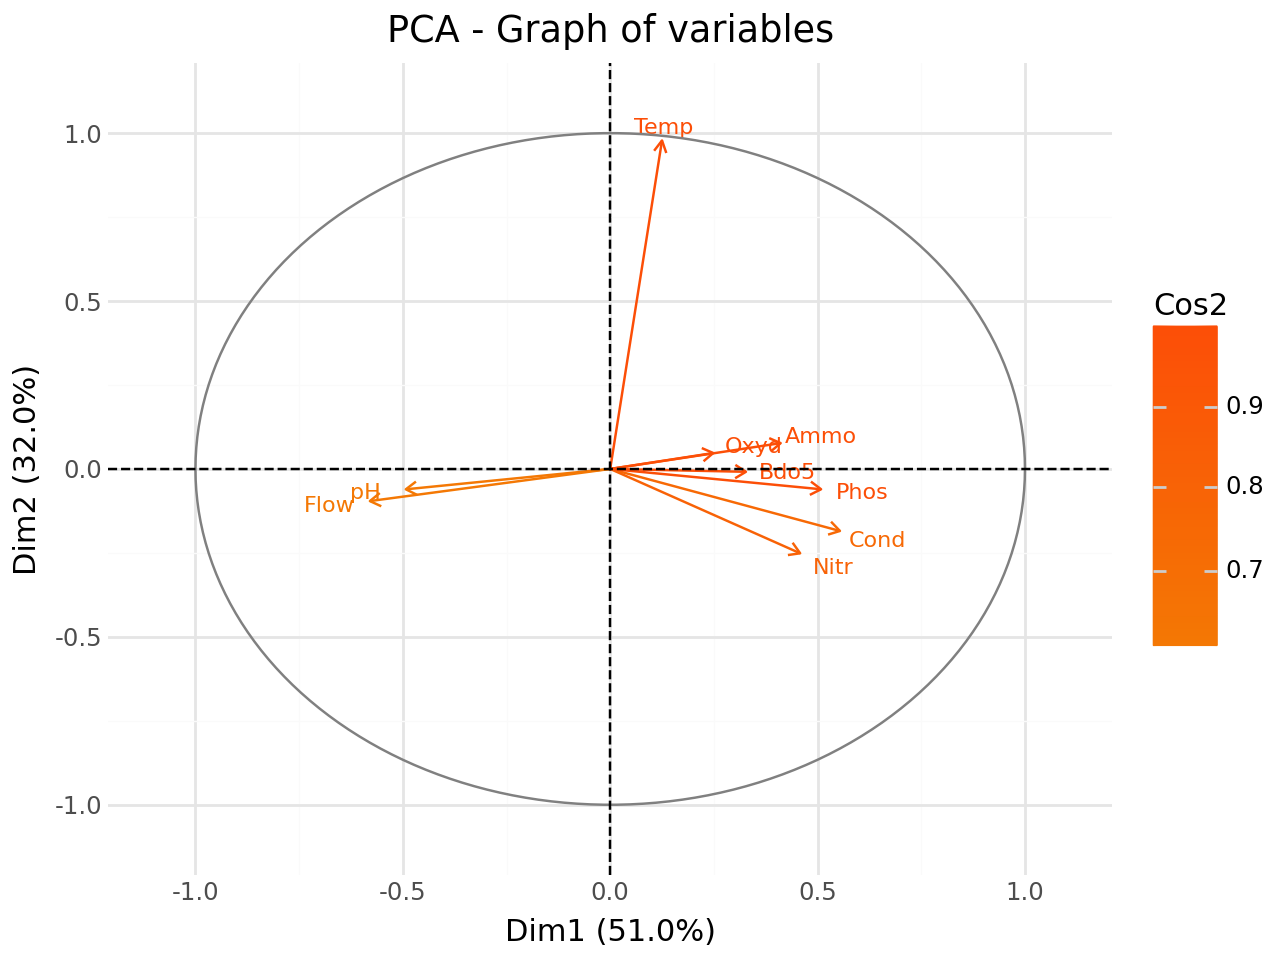

None


In [36]:
# graph of variables - color by cosinus
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "cos2",
    repel=True,
    quanti_sup=False
)
print(p.show())

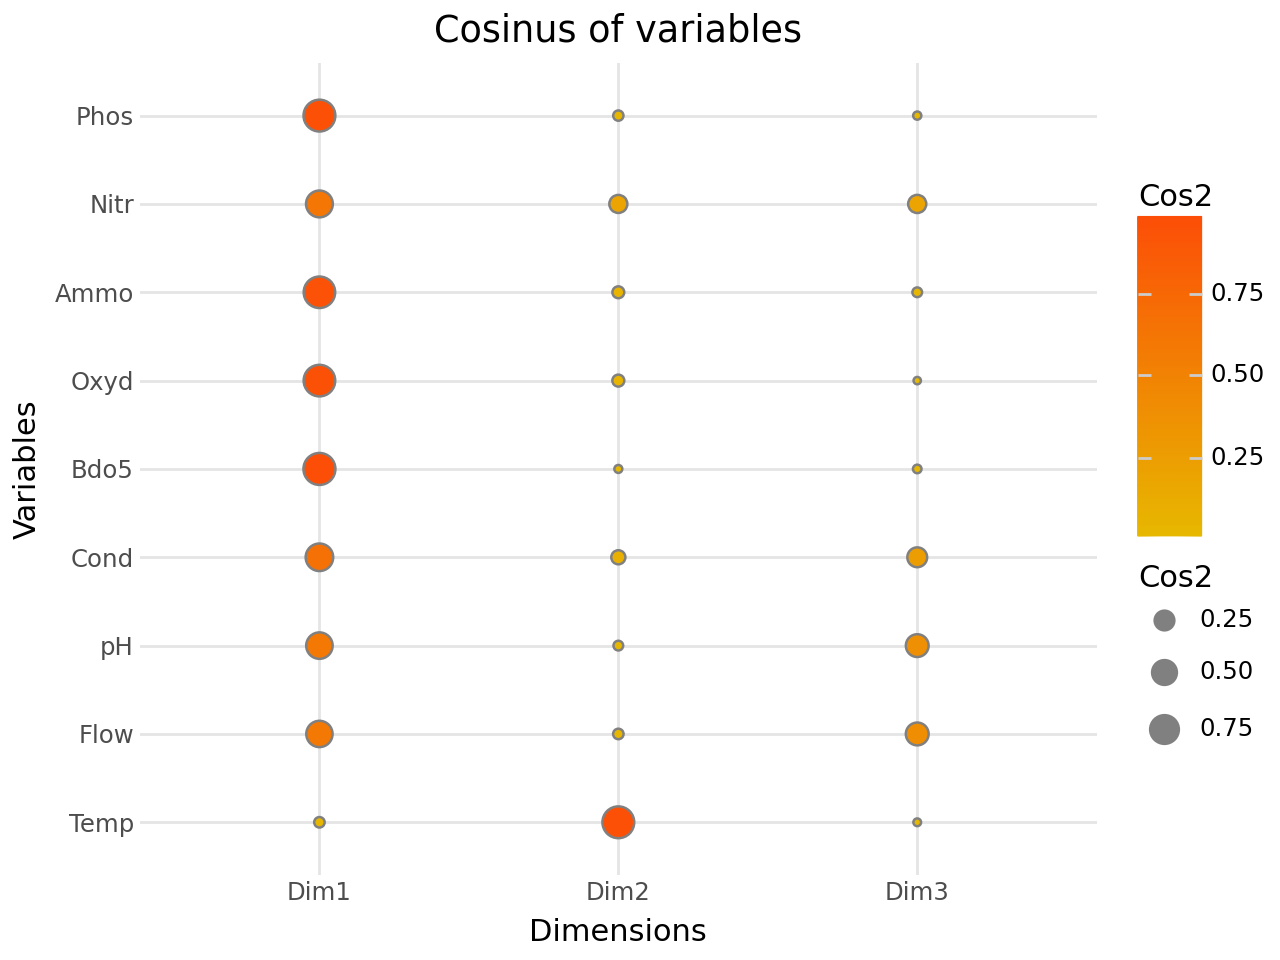

None


In [37]:
# graph of cosinus for variables
p = fviz_corrplot(
    X=var.cos2,
    legend_title="Cos2",
    title="Cosinus of variables"
)
print(p.show())

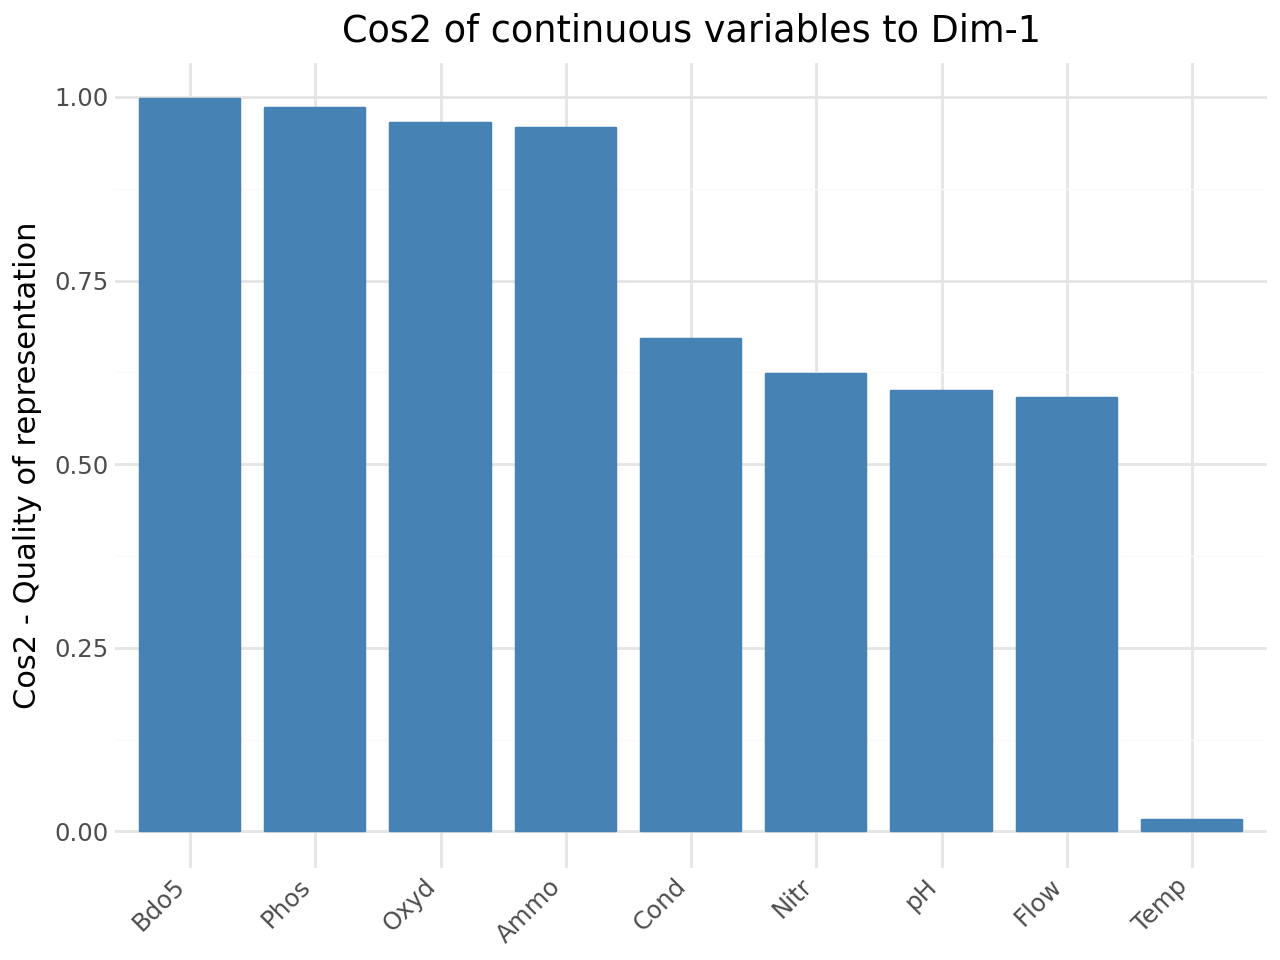

None


In [38]:
# cosinus of variables to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables additionals informations

In [39]:
# variables additionals informations
var.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
Temp,1.0,0.972423,0.972423,29.023944
Flow,1.0,0.568331,0.568331,16.962986
pH,1.0,0.404511,0.404511,12.073459
Cond,1.0,0.457820,0.457820,13.664552
Bdo5,1.0,0.107435,0.107435,3.206625
Oxyd,1.0,0.063984,0.063984,1.909739
Ammo,1.0,0.176387,0.176387,5.264624
Nitr,1.0,0.337122,0.337122,10.062097
Phos,1.0,0.262404,0.262404,7.831973


## Supplementary quantitative variables

In [40]:
#supplementary quantitative variables
quanti_var_sup = clf.quanti_var_sup_
quanti_var_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary quantitative variables coordinates

In [41]:
# supplementary quantitative variables coordinates
quanti_var_sup.coord

,Dim1,Dim2,Dim3
Ephemera_danica,0.110552,-0.000737,-0.026096
Baetis_sp,0.233006,-0.195278,-0.094549
Baetis_rhodani,0.333857,0.025449,0.005766
Baetis_niger,-0.217966,0.253720,-0.163744
Baetis_muticus,0.305274,-0.128437,0.095667
Centroptilum_sp,-0.116231,-0.536037,0.497885
Ecdyonorus_sp,-0.033844,-0.151822,0.027712
Rhithrogena_sp,-0.257704,-0.456752,-0.066978
Habrophlebia_lauta,-0.378803,-0.143886,-0.248989
Habroleptoides_sp,0.068840,-0.409019,-0.046454


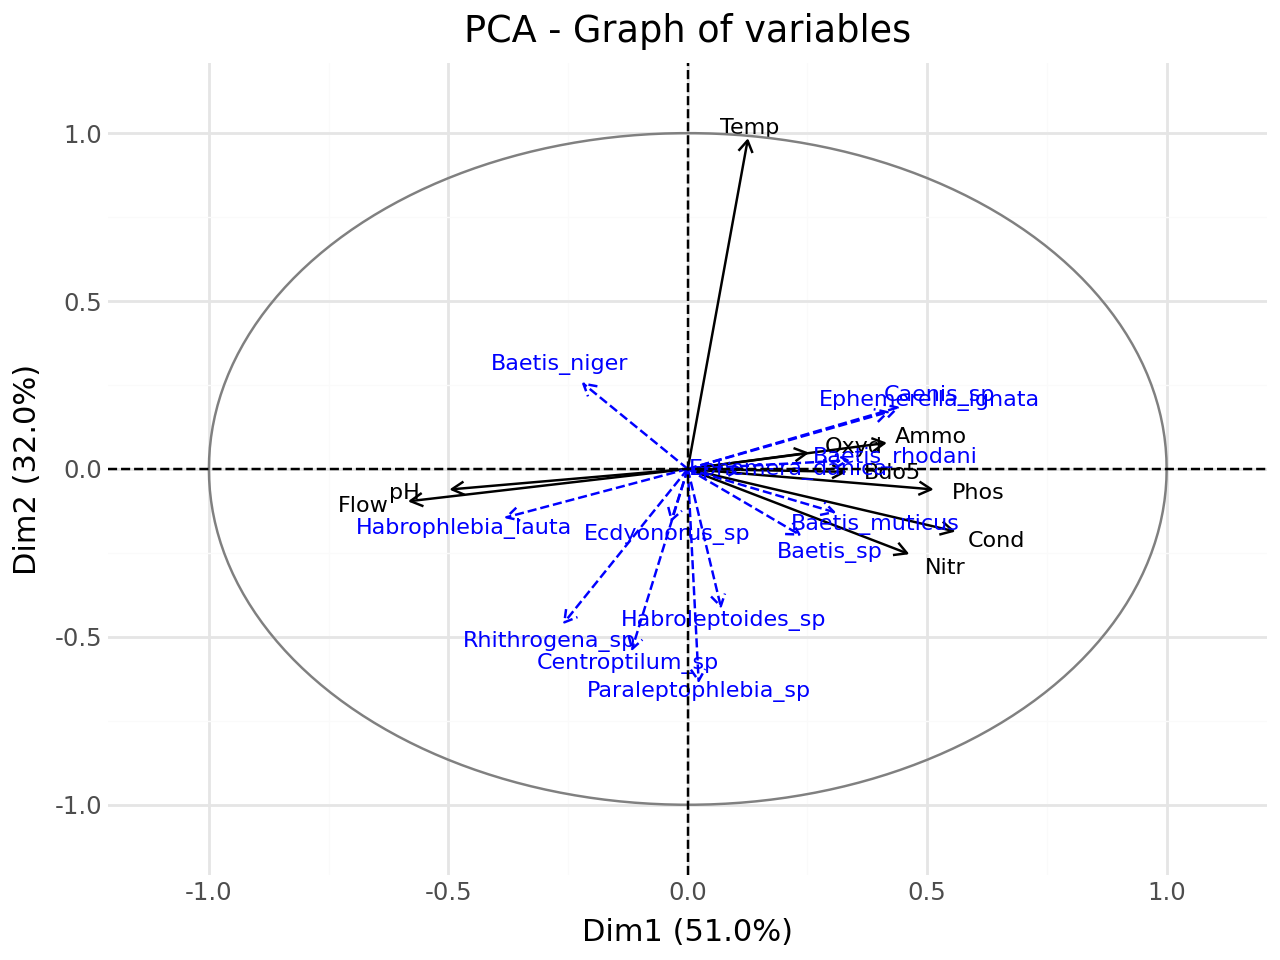

None


In [42]:
# graph of variables with supplementary quantitative variables
p = fviz_pca(
    obj=clf,
    choice="var",
    repel=True,
    quanti_sup = True
)
print(p.show())

### Supplementary quantitative variables cos2

In [43]:
# supplementary quantitative variables cos2
quanti_var_sup.cos2

,Dim1,Dim2,Dim3
Ephemera_danica,0.947181,0.000042,0.052777
Baetis_sp,0.535608,0.376200,0.088192
Baetis_rhodani,0.993928,0.005775,0.000297
Baetis_niger,0.342543,0.464140,0.193317
Baetis_muticus,0.784180,0.138809,0.077012
Centroptilum_sp,0.024620,0.523633,0.451747
Ecdyonorus_sp,0.045885,0.923352,0.030763
Rhithrogena_sp,0.237591,0.746360,0.016049
Habrophlebia_lauta,0.634385,0.091530,0.274085
Habroleptoides_sp,0.027205,0.960407,0.012388


## Supplementary levels informations

In [44]:
# supplementary levels informations
levels_sup = clf.levels_sup_
levels_sup._fields

('coord', 'cos2', 'dist2', 'vtest')

### Supplementary levels coordinates

In [45]:
# supplementary levels coordinates
levels_sup.coord

,Dim1,Dim2,Dim3
S1,-1.031319,0.129595,-0.716638
S2,1.870145,0.185606,1.009994
S3,0.781546,-0.189209,0.144655
S4,-0.482387,-0.027179,0.024578
S5,-1.137985,-0.098815,-0.462588


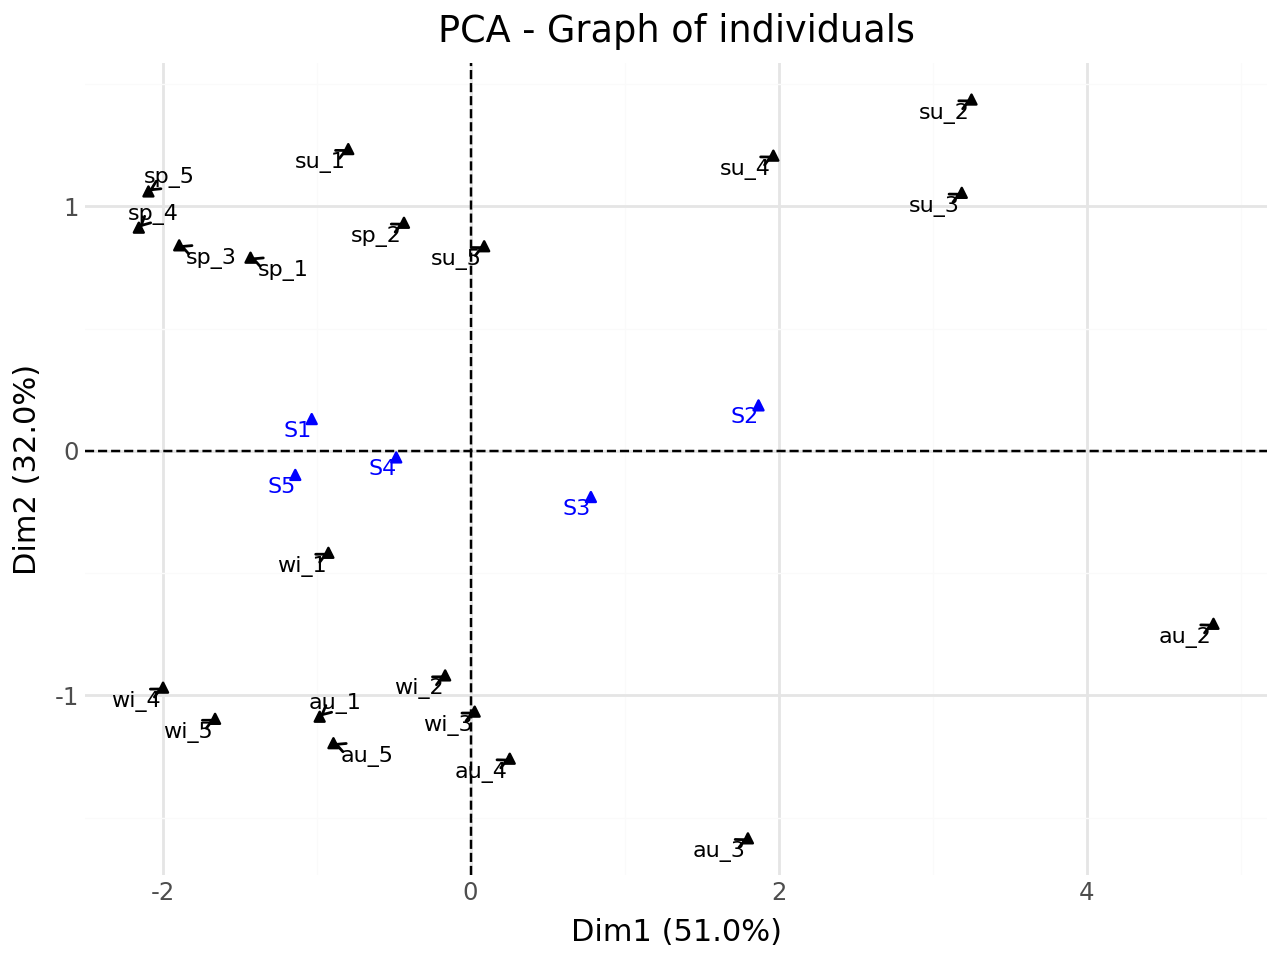

None


In [46]:
# graph of individuals
from plotnine import ggplot
from scientisttools import add_scatter, set_axis
# draw individuals coordinates
p = add_scatter(
    p=ggplot(),
    data=ind.coord,
    color="black",
    repel=True
)
# add levels coordinates
p = add_scatter(
    p=p,
    data=levels_sup.coord,
    color="blue",
    repel=True
)
# set axis
p = set_axis(
    p = p,
    obj=clf,
    title = "PCA - Graph of individuals"
)
print(p.show())

### Supplementary levels vtest

In [47]:
# supplementary levels vtest
levels_sup.vtest

,Dim1,Dim2,Dim3
S1,-1.720501,0.271983,-2.077449
S2,3.119875,0.389533,2.927853
S3,1.303817,-0.397093,0.419337
S4,-0.804744,-0.057040,0.071248
S5,-1.898446,-0.207383,-1.340989


### Supplementary levels cos2

In [48]:
# supplementary levels cos2
levels_sup.cos2

,Dim1,Dim2,Dim3
S1,0.284262,0.004489,0.137256
S2,0.386351,0.003806,0.112686
S3,0.648812,0.038027,0.022227
S4,0.252956,0.000803,0.000657
S5,0.524831,0.003957,0.086723


### Supplementary levels dist2

In [49]:
# supplementary levels dist2
levels_sup.dist2.to_frame()

,Sq. Dist.
S1,3.741684
S2,9.052508
S3,0.941435
S4,0.919915
S5,2.467478


## Supplementary qualitative variables informations

In [50]:
# supplementary qualitative variables
quali_var_sup = clf.quali_var_sup_
quali_var_sup._fields

('coord',)

### Supplementary qualitative variables coordinates

In [51]:
# supplementary qualitative variables coordinates
quali_var_sup.coord

,Dim1,Dim2,Dim3
site,0.35243,0.017329,0.280596
